# `hem_rect_fill` vs. `default_51`, `human neuroendocrine tumor` only -- an isolated, higher-n follow-up

**Why.** `production_hematoxylin_only/hem_rect_fill_vs_default_chromatin_od_by_domain.ipynb` sliced the
49-ROI result by domain and found `human neuroendocrine tumor` the one domain with a small, broad
(non-single-ROI), consistently negative direction at every K -- but n = 7 ROIs cannot resolve it. A
power calculation from that domain's own observed variance put the ROI count needed at roughly 11-33
depending on K and how conservatively the correction is read. This notebook pulls more ROIs of that one
domain and re-runs the same two-arm test at n = 22.

**Isolation.** Everything for this follow-up lives in `human_neuroendocrine_followup/`: the pulled
images (`images/`, see `MANIFEST.md`), this notebook, and its own `results/`. Nothing is written to the
main repo's `images/`, `images/extra_valid/`, or `results/`. The main repo's recorded
`hemrectfill` run is read **read-only**, only to reuse the 7 already-used ROIs' exact clicks.

**ROIs (22 total, see `MANIFEST.md` and `results/pull_verification.csv` for the full pull).**
- **7 `existing_7`** -- already used in the 49-ROI domain analysis. Their clicks are **reused verbatim**
  from the recorded `hemrectfill` run, not redrawn, so this notebook's n = 22 result is a strict
  superset of the n = 7 domain result, not an independent redraw of everything.
- **9 `unanimous_new`** -- new ROIs, unanimous-tier mitotic annotations (`agreement_pool` non-contested).
- **6 `contested_2of3`** -- new ROIs, backfilled from `agreement_pool`'s contested 2-of-3 tier because
  the unanimous tier is exhausted (no unflagged image in the domain has a usable pool left). Reported as
  its own tier throughout, never silently merged with the unanimous ROIs.

**Relaxed inclusion bar.** The repo's usual "decision-grade" bar (`n_mitotic >= 15`, seed pool `>= 5`)
leaves exactly one unused valid ROI in this domain. This follow-up instead requires only what the
experiment itself needs: at least 3 mitotic annotations that pass `agreement_pool` -> `border_filter(36)`
-> `tighten_box_otsu` -- the same gate `hem_rect_fill`'s own template cut already applies. See
`MANIFEST.md` for the full rationale and the 5 downloaded-but-excluded ROIs that fell short of it.

**Everything else matches the parent notebook exactly**, same as every prior notebook in this family:
- `default_51`: the 51x51 `hematoxylin_od` window centred on the click.
- `hem_rect_fill`: the same array, pixels outside the hematoxylin Otsu rectangle set to their own mean.
- Search image `hematoxylin_od` (25 px replicate pad), peak/NMS/self-hit settings (`PEAK_MIN_DISTANCE` 7,
  `DEEP_FLOOR_Z` -1.5, `MAX_PEAKS` 100, NMS radius = match radius = 7.5 um, `SELF_HIT_RADIUS` 5 px),
  ranking by `chromatin_od` (51 px window), greedy centre-distance matching with the click's own
  annotation removed from ground truth.
- No joint gate: unlike the 3-way bbox notebooks, only two arms are compared here and both read the same
  template pixels at the same size and centre, so the only per-click requirement is that
  `tighten_box_otsu` succeeds -- exactly the click-gate this notebook draws against.

**Parity.** For the 7 `existing_7` ROIs only, both arms are re-run here and checked against the recorded
`hemrectfill` run's `n_peaks`/`n_detections`/`n_self_hits`/TP@K (not the full top-30 od bit-exactness the
parent notebooks check -- a deliberate scope reduction for this follow-up, noted here rather than left
implicit). The 15 new ROIs have no recorded reference; their correctness rests on reusing the identical,
already-verified pipeline code.

**Statistics.** Same design as the domain-breakdown notebook: ROI is the unit, delta is
`hem_rect_fill - default_51` TP@K summed over 3 clicks, pooled precision delta with a cluster-bootstrap
95% CI over the 22 ROIs, a t interval, ROI-level W/L/T, an exact sign-flip p, Holm over the 3 K. The
n = 22 result is placed directly alongside the recorded n = 7 domain-only result for comparison.

**Reading rules, fixed before the numbers below were read.** Same as every notebook in this family:
bootstrap CI excludes 0 and negative -> `default_51` higher; excludes 0 and positive -> `hem_rect_fill`
higher; includes 0 -> no difference detected, CI quoted as a bound only.

**Pipeline version -- read before trusting this against the shipping pipeline.** The recorded
`hemrectfill` run this notebook reuses 7 ROIs' clicks from predates **D11**
(`9e22eb9`, 2026-09-17): its `per_run.csv` has a populated `n_self_hits` column, an info key D11
deleted outright when it replaced the post-NMS self-hit-disc filter with blanking the seed's template
footprint before correlation. `midog_utils.production` no longer exposes `SELF_HIT_RADIUS` at all. This
notebook **deliberately reproduces the pre-D11 self-hit-disc pipeline** (pinning `SELF_HIT_RADIUS = 5.0`
locally, not read from `production`) so its 15 new ROIs stay poolable with the 7 reused ones -- pooling
a pre-D11 measurement with a D11 one under one n = 22 result would be invalid regardless of which
constant each part used. **Consequence:** this result is about the pre-D11 method. It does not describe
current production's D11 behaviour, and does not transfer to the shipping pipeline without a separate
D11-era re-measurement.

**Caveats.**
- n = 22 is still short of this domain's own Holm-worst-case power target at K = 20 (~33); it clears the
  plain-alpha targets at K = 10/30 and is close at K = 20.
- 6 of 22 ROIs use the contested (2-of-3) annotation tier, not the unanimous tier the rest of the repo
  uses exclusively -- and tier is confounded with ROI character (the 7 existing ROIs are all
  high-density decision-grade; the contested ones are not), not just annotation confidence. A sensitivity
  row recomputes every stat on the 16 non-contested ROIs alone.
- `chromatin_od` ranking only; one domain; one fill rule.
- This repo lives under iCloud Desktop & Documents sync on a near-full disk, so a just-read file can be
  evicted and need re-fetching; `materialize()` (from `pull_rois.py`) is called before every image load.

In [1]:
import gc
import hashlib
import math
import sys
import time
from fractions import Fraction
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
from scipy import stats as sps
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

sys.path.insert(0, '..')
from midog_utils import channels as ch
from midog_utils import chromatin as cm
from midog_utils import dataset as ds
from midog_utils import evaluate as ev
from midog_utils import invariants as inv
from midog_utils import production as prod
from midog_utils import seed_selection as ss
from midog_utils import template_match as tm
from midog_utils.nms import nms_by_distance
from pull_rois import materialize

pd.set_option('display.width', 250)
pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 400)
pd.set_option('display.max_colwidth', 140)

NB_T0 = time.time()

REFERENCE_CONFIG = dict(CHANNEL='hematoxylin_od', TM_METHOD=cv2.TM_CCOEFF, PEAK_MIN_DISTANCE=7, DEEP_FLOOR_Z=-1.5, MAX_PEAKS=100, OD_WINDOW=51)
CONFIG_DRIFT = pd.DataFrame([dict(setting=k, production_py=getattr(prod, k), reference=v, match=getattr(prod, k) == v) for k, v in REFERENCE_CONFIG.items()])
print(CONFIG_DRIFT.to_string(index=False))
assert CONFIG_DRIFT['match'].all(), 'midog_utils.production no longer matches this notebook family\'s configuration'
assert ev.MIDOG_RADIUS_UM == 7.5 and tm.BASE_SIZE == 51 and tm.PATCH_SIZE == 73 and prod.OD_WINDOW // 2 == 25

# D11 (9e22eb9, 2026-09-17) replaced the post-NMS self-hit-disc filter with blanking the seed's
# template footprint before correlation, and deleted production.SELF_HIT_RADIUS along with it. This
# notebook deliberately reproduces the pre-D11 pipeline (see header) so its new ROIs stay poolable
# with the 7 reused from the pre-D11 recorded hemrectfill run -- so SELF_HIT_RADIUS is pinned here,
# not read from production. If production ever gets SELF_HIT_RADIUS back, D11 was reverted and this
# notebook's premise (reproducing the *retired* mechanism on purpose) needs re-checking, hence the halt.
assert not hasattr(prod, 'SELF_HIT_RADIUS'), 'production has SELF_HIT_RADIUS again -- D11 may have been reverted; re-check which mechanism this notebook should reproduce'
SELF_HIT_RADIUS = 5.0  # pinned pre-D11 value, deliberately not read from production (see above)

DOMAIN = 'human neuroendocrine tumor'
ARMS = ('default_51', 'hem_rect_fill')
BUDGETS = (10, 20, 30)
SEED_INDICES = (0, 1, 2)
N_BOOT = 10_000
BOOT_SEED = 20260922
BORDER = 36
HRF_MAIN = '../results/precision_at_k_49roi_3seed_chromatin_hemrectfill'  # read-only reference
OUT = {name: f'results/neuro_followup_22roi_3seed_{name}.csv' for name in ('clicks', 'per_run', 'top30', 'per_roi', 'delta_per_roi', 'delta_stats')}
FIG_PATHS = {'forest': 'neuro_followup_n7_vs_n22_forest.png', 'strip': 'neuro_followup_22roi_strip.png'}
Path('results').mkdir(exist_ok=True)

print(f"\ndomain {DOMAIN!r}; arms {ARMS}; K = {BUDGETS}; cluster bootstrap B = {N_BOOT} (seed {BOOT_SEED})")
print('outputs:', *OUT.values(), *FIG_PATHS.values(), sep='\n  ')

          setting  production_py      reference  match
          CHANNEL hematoxylin_od hematoxylin_od   True
        TM_METHOD              4              4   True
PEAK_MIN_DISTANCE              7              7   True
     DEEP_FLOOR_Z           -1.5           -1.5   True
        MAX_PEAKS            100            100   True
        OD_WINDOW             51             51   True

domain 'human neuroendocrine tumor'; arms ('default_51', 'hem_rect_fill'); K = (10, 20, 30); cluster bootstrap B = 10000 (seed 20260922)
outputs:
  results/neuro_followup_22roi_3seed_clicks.csv
  results/neuro_followup_22roi_3seed_per_run.csv
  results/neuro_followup_22roi_3seed_top30.csv
  results/neuro_followup_22roi_3seed_per_roi.csv
  results/neuro_followup_22roi_3seed_delta_per_roi.csv
  results/neuro_followup_22roi_3seed_delta_stats.csv
  neuro_followup_n7_vs_n22_forest.png
  neuro_followup_22roi_strip.png


In [2]:
REPORT = pd.read_csv('results/pull_verification.csv')
ROIS = REPORT[REPORT['n_gate_valid'] >= 3].sort_values(['tier', 'file_name']).reset_index(drop=True)
assert len(ROIS) == 22, f'{len(ROIS)} usable ROIs, expected 22'
assert (ROIS['checks_passed'] == 'ALL').all(), 'a usable ROI failed a basic check'
assert set(ROIS['tier']) == {'existing_7', 'unanimous_new', 'contested_2of3'}
print(ROIS['tier'].value_counts().to_string())

images, annotations = ds.load_annotations('../databases/MIDOG++.json')
assert (images.loc[images['file_name'].isin(ROIS['file_name']), 'tumor_type'] == DOMAIN).all(), 'a pulled ROI is not human neuroendocrine tumor per the JSON'

EXISTING_7 = ROIS.loc[ROIS['tier'] == 'existing_7', 'file_name'].tolist()
NEW_15 = ROIS.loc[ROIS['tier'] != 'existing_7', 'file_name'].tolist()
print(f"{len(ROIS)} ROIs: {len(EXISTING_7)} existing (clicks reused) + {len(NEW_15)} new (clicks drawn here)")

tier
unanimous_new     9
existing_7        7
contested_2of3    6


22 ROIs: 7 existing (clicks reused) + 15 new (clicks drawn here)


In [3]:
def draw_click(pool, rng, hem):
    """
        Draw one click the hem_rect_fill template can be built from, redrawing on the same RNG
        stream after a refusal -- draw_joint_click's walk (bbox_refinement_three_way_...), with a
        single condition: tighten_box_otsu succeeds on the 51 px hem window and the 73 px
        rotation-safe patch is readable.

        pool (pd.DataFrame): the border-filtered pool, minus the clicks earlier seeds accepted.
        rng (np.random.Generator): this seed's [seed_index, image_id] stream.
        hem (np.ndarray): this ROI's hematoxylin_od channel.

        Returns tuple[pd.Series, list[int]]: the accepted annotation, and the ann_ids refused before it.
    """
    working, refusals = pool.copy(), []
    while len(working) > 0:
        idx = int(rng.integers(len(working)))
        row = working.iloc[idx]
        cx, cy = float(row['cx']), float(row['cy'])
        ok = tm.read_padded_patch(hem, cx, cy, tm.PATCH_SIZE) is not None
        if ok:
            window = tm.read_padded_patch(hem, cx, cy, tm.BASE_SIZE)
            ok = window is not None and ss.tighten_box_otsu(window) is not None
        if ok:
            return row, refusals
        refusals.append(int(row['ann_id']))
        working = working.drop(working.index[idx])
    raise ValueError('gate-valid pool exhausted -- fewer than 3 distinct clicks available')


new_rows = []
for r in ROIS[ROIS['tier'] != 'existing_7'].itertuples():
    fn, image_id = r.file_name, int(r.image_id)
    path = Path('images') / fn
    materialize(path)
    rgb = ds.load_roi(path)
    mpp = ds.roi_mpp(path)
    hem = ch.to_channel(rgb, 'hematoxylin_od')
    gt = ds.image_annotations(annotations, fn)
    mit = gt[gt['category_id'] == ds.MITOTIC]
    pool, flagged = ss.agreement_pool(mit)
    pool = ss.border_filter(pool, BORDER, rgb.shape)

    accepted = []
    for seed_index in SEED_INDICES:
        seed_pool = pool[~pool['ann_id'].isin(accepted)] if accepted else pool
        rng = np.random.default_rng([seed_index, image_id])
        row, refusals = draw_click(seed_pool, rng, hem)
        accepted.append(int(row['ann_id']))
        new_rows.append(dict(subset=r.tier, roi_tier=r.tier, domain=DOMAIN, file_name=fn, image_id=image_id, seed_index=seed_index,
                              seed_ann_id=int(row['ann_id']), click_cx=float(row['cx']), click_cy=float(row['cy']), mpp=float(mpp),
                              match_radius_px=float(ev.radius_px(mpp)), n_gt_mitotic=int(len(mit)), n_retries=len(refusals),
                              refused_draws=';'.join(map(str, refusals)), agreement_flagged=bool(flagged)))
    del rgb, hem
    gc.collect()

NEW_CLICKS = pd.DataFrame(new_rows)
assert len(NEW_CLICKS) == 3 * len(NEW_15), f'{len(NEW_CLICKS)} new clicks, expected {3 * len(NEW_15)}'
assert NEW_CLICKS.groupby('file_name')['seed_ann_id'].nunique().eq(3).all(), 'a new ROI did not draw 3 distinct clicks'
print(f"{len(NEW_CLICKS)} clicks drawn on {len(NEW_15)} new ROIs; total retries (refused draws) = {NEW_CLICKS['n_retries'].sum()}; contested-tier clicks = {int(NEW_CLICKS['agreement_flagged'].sum())}")
print(NEW_CLICKS[['file_name', 'seed_index', 'seed_ann_id', 'n_retries', 'agreement_flagged']].to_string(index=False))

45 clicks drawn on 15 new ROIs; total retries (refused draws) = 3; contested-tier clicks = 18
file_name  seed_index  seed_ann_id  n_retries  agreement_flagged
 350.tiff           0        18164          0               True
 350.tiff           1        18161          0               True
 350.tiff           2        18156          0               True
 361.tiff           0        18582          0               True
 361.tiff           1        18638          0               True
 361.tiff           2        18580          0               True
 373.tiff           0        18988          0               True
 373.tiff           1        18981          0               True
 373.tiff           2        18989          0               True
 379.tiff           0        19152          0               True
 379.tiff           1        19141          0               True
 379.tiff           2        19160          0               True
 383.tiff           0        19291          0               T

In [4]:
REC_RUN = pd.read_csv(f'{HRF_MAIN}_per_run.csv', float_precision='round_trip')
exist = REC_RUN[(REC_RUN['domain'] == DOMAIN) & (REC_RUN['condition'] == 'default_51') & (REC_RUN['file_name'].isin(EXISTING_7))].copy()
assert len(exist) == 3 * len(EXISTING_7), f'{len(exist)} recorded clicks for the existing 7, expected {3 * len(EXISTING_7)}'

for r in exist.itertuples():
    match = annotations[(annotations['ann_id'] == r.seed_ann_id) & (annotations['file_name'] == r.file_name)]
    assert len(match) == 1, f'{r.file_name} s{r.seed_index}: {len(match)} annotation rows for ann_id {r.seed_ann_id}'
    assert match['category_id'].iat[0] == ds.MITOTIC and match['cx'].iat[0] == r.click_cx and match['cy'].iat[0] == r.click_cy, f'{r.file_name} s{r.seed_index}: recorded click does not match the JSON annotation'

EXIST_CLICKS = exist[['subset', 'domain', 'file_name', 'image_id', 'seed_index', 'seed_ann_id', 'click_cx', 'click_cy', 'mpp', 'match_radius_px', 'n_gt_mitotic']].copy()
EXIST_CLICKS['roi_tier'] = 'existing_7'
EXIST_CLICKS['n_retries'] = -1  # not recorded for the original draw; clicks are reused verbatim, not redrawn here
EXIST_CLICKS['refused_draws'] = ''
EXIST_CLICKS['agreement_flagged'] = False
print(f"{len(EXIST_CLICKS)} clicks reused verbatim from the recorded hemrectfill run on the 7 existing ROIs; every seed_ann_id verified against the JSON")

21 clicks reused verbatim from the recorded hemrectfill run on the 7 existing ROIs; every seed_ann_id verified against the JSON

In [5]:
CLICKS = pd.concat([EXIST_CLICKS[NEW_CLICKS.columns], NEW_CLICKS], ignore_index=True)
assert len(CLICKS) == 3 * len(ROIS) == 66, f'{len(CLICKS)} total clicks, expected 66'
assert CLICKS.groupby('file_name')['seed_index'].apply(lambda s: sorted(s) == list(SEED_INDICES)).all()

ROI_ORDER = ROIS['file_name'].tolist()
CLICKS['file_name'] = pd.Categorical(CLICKS['file_name'], categories=ROI_ORDER, ordered=True)
CLICKS = CLICKS.sort_values(['file_name', 'seed_index']).reset_index(drop=True)
CLICKS['file_name'] = CLICKS['file_name'].astype(str)
CLICKS.to_csv(OUT['clicks'], index=False)
print(f"{len(CLICKS)} clicks on {len(ROI_ORDER)} ROIs, in ROI_ORDER x seed_index order")
print(f"-> {OUT['clicks']}")

66 clicks on 22 ROIs, in ROI_ORDER x seed_index order
-> results/neuro_followup_22roi_3seed_clicks.csv


In [6]:
def cut_templates(hem, cx, cy):
    """
        The default 51 px template for one click, and the same template flattened outside the
        hematoxylin Otsu rectangle -- identical to hem_rect_fill_vs_default_chromatin_od_49roi_3seed.

        hem (np.ndarray): this ROI's hematoxylin_od channel.
        cx (float): click x, full-image pixels.
        cy (float): click y, full-image pixels.

        Returns dict: T (default_51 template), F (hem_rect_fill template), rect, fill (fill value), n_filled.
    """
    patch = tm.read_padded_patch(hem, cx, cy, tm.PATCH_SIZE)
    assert patch is not None, f'({cx}, {cy}): the 73 px patch is not readable'
    templates, _ = tm.build_augmentations(patch, tm.BASE_SIZE, (1.0,), 1, (False,))
    T = templates[0]
    assert T.shape == (51, 51) and T.dtype == np.float32
    W = tm.read_padded_patch(hem, cx, cy, tm.BASE_SIZE)
    assert np.array_equal(W, T)
    rect = ss.tighten_box_otsu(W)
    assert rect is not None, f'({cx}, {cy}): tighten_box_otsu refused the window'
    y0, y1, x0, x1 = rect
    outside = np.ones((51, 51), bool)
    outside[y0:y1, x0:x1] = False
    fill = np.float32(T[outside].astype(np.float64).mean())
    F = T.copy()
    F[outside] = fill
    return dict(T=T, F=F, rect=rect, fill=fill, n_filled=int(outside.sum()))


def run_template(hem_padded, shape, template, cx, cy, mpp):
    """
        Search one 51 px template over the ROI and rank candidates by chromatin_od -- identical
        pipeline to the parent notebooks.

        hem_padded (np.ndarray): hematoxylin_od channel, replicate-padded by 25 px.
        shape (tuple): the unpadded channel's (height, width).
        template (np.ndarray): the 51x51 float32 template.
        cx (float): click x, the self-hit centre.
        cy (float): click y, the self-hit centre.
        mpp (float): the ROI's microns per pixel.

        Returns tuple[pd.DataFrame, dict]: detections ranked by od, and n_peaks/n_detections/n_self_hits.
    """
    nms_radius = ev.radius_px(mpp)
    inv.check_nms_radius(nms_radius, mpp, label='neuro_followup')
    pad = 25
    h, w = shape
    fused_p, best_p, valid_p = tm.fused_response(hem_padded, [template], False, method=prod.TM_METHOD)
    fused = fused_p[pad:pad + h, pad:pad + w]
    valid = valid_p[pad:pad + h, pad:pad + w]
    assert valid.all(), 'the 25 px pad left part of the ROI unreachable'
    med, mad = tm.robust_stats(fused, valid)
    threshold = med + prod.DEEP_FLOOR_Z * mad
    centers, scores = tm.extract_peaks(fused, valid, prod.PEAK_MIN_DISTANCE, threshold, prod.MAX_PEAKS)
    n_peaks = len(centers)
    keep = nms_by_distance(centers, scores, nms_radius)
    centers, scores = centers[keep], scores[keep]
    self_hit = np.hypot(centers[:, 0] - float(cx), centers[:, 1] - float(cy)) <= SELF_HIT_RADIUS
    n_self_hits = int(self_hit.sum())
    centers, scores = centers[~self_hit], scores[~self_hit]
    det = pd.DataFrame({'rank': np.arange(len(centers)), 'cx': centers[:, 0], 'cy': centers[:, 1], 'score': scores})
    shifted = det.assign(cx=det['cx'] + 25, cy=det['cy'] + 25)
    det = det.assign(od=cm.score_detections(shifted, hem_padded, window=prod.OD_WINDOW)['od'].to_numpy())
    det = det.sort_values('od', ascending=False, na_position='last', kind='mergesort').reset_index(drop=True)
    det = det.assign(rank=np.arange(len(det)))
    return det, {'n_peaks': n_peaks, 'n_detections': len(det), 'n_self_hits': n_self_hits}


def score_top_k(detections, gt_eval, match_radius):
    """
        Match a ranked detection list to ground truth and count true positives in each top-K.

        detections (pd.DataFrame): ranked detections, best first.
        gt_eval (pd.DataFrame): ground truth with the click's own annotation removed.
        match_radius (float): match radius in pixels.

        Returns tuple[pd.DataFrame, dict]: the detections with match buckets added, and K -> true positives in the top K.
    """
    det_out, _ = ev.bucket_detections(detections, gt_eval, match_radius)
    hit = (det_out['bucket'] == ev.HUMAN_CORRECT_LABEL).to_numpy()
    return det_out, {k: int(hit[:k].sum()) for k in BUDGETS}


def parity_gate(tag, info, tp, ref_row):
    """
        Assert a re-run click on an existing_7 ROI reproduces the recorded hemrectfill run's
        n_peaks/n_detections/n_self_hits/TP@K (not the full top-30 od bit-exactness the parent
        notebooks check -- see this notebook's header for that scope reduction).

        tag (str): names the click and arm in the assertion message.
        info (dict): this re-run's n_peaks, n_detections, n_self_hits.
        tp (dict): this re-run's K -> true positives.
        ref_row (pd.Series): the recorded per_run row for this click and arm.
    """
    assert (info['n_peaks'], info['n_detections'], info['n_self_hits']) == (ref_row['n_peaks'], ref_row['n_detections'], ref_row['n_self_hits']), \
        f"{tag}: (n_peaks, n_detections, n_self_hits) {(info['n_peaks'], info['n_detections'], info['n_self_hits'])} != recorded {(ref_row['n_peaks'], ref_row['n_detections'], ref_row['n_self_hits'])}"
    assert all(tp[k] == ref_row[f'tp_at_{k}'] for k in BUDGETS), f"{tag}: TP@K {tp} != recorded {[ref_row[f'tp_at_{k}'] for k in BUDGETS]}"

In [7]:
REC_RUN_IDX = REC_RUN.set_index(['file_name', 'seed_index', 'condition'])

per_run_rows, top_frames = [], []
n_parity = 0
t_loop = time.time()
for i, file_name in enumerate(ROI_ORDER):
    rows = CLICKS[CLICKS['file_name'] == file_name].sort_values('seed_index')
    assert rows['seed_index'].tolist() == list(SEED_INDICES)
    is_existing = rows['roi_tier'].iat[0] == 'existing_7'

    path = Path('images') / file_name
    materialize(path)
    rgb = ds.load_roi(path)
    mpp = ds.roi_mpp(path)
    assert abs(mpp - rows['mpp'].iat[0]) < 1e-6, f'{file_name}: mpp {mpp!r} != recorded {rows["mpp"].iat[0]!r}'
    hem = ch.to_channel(rgb, 'hematoxylin_od')
    hem_padded = cv2.copyMakeBorder(hem, 25, 25, 25, 25, borderType=cv2.BORDER_REPLICATE)
    gt = ds.image_annotations(annotations, file_name)
    match_radius = ev.radius_px(mpp)

    progress = []
    for _, r in rows.iterrows():
        cx, cy, s = float(r.click_cx), float(r.click_cy), int(r.seed_index)
        tag = f'{file_name} s{s}'
        cut = cut_templates(hem, cx, cy)
        gt_eval = gt[gt['ann_id'] != r.seed_ann_id].reset_index(drop=True)

        tp_by_arm = {}
        for arm, template in (('default_51', cut['T']), ('hem_rect_fill', cut['F'])):
            det, info = run_template(hem_padded, hem.shape, template, cx, cy, mpp)
            out, tp = score_top_k(det, gt_eval, match_radius)
            if is_existing:
                parity_gate(f'{tag} {arm}', info, tp, REC_RUN_IDX.loc[(file_name, s, arm)])
                n_parity += 1
            tpl_sha1 = hashlib.sha1(template.tobytes()).hexdigest()
            d_click = np.hypot(out['cx'].to_numpy() - cx, out['cy'].to_numpy() - cy)
            near = np.flatnonzero(d_click <= match_radius)
            per_run_rows.append(dict(subset=r.subset, roi_tier=r.roi_tier, domain=DOMAIN, file_name=file_name, image_id=int(r.image_id),
                                      seed_index=s, condition=arm, seed_ann_id=int(r.seed_ann_id), click_cx=cx, click_cy=cy, mpp=mpp,
                                      match_radius_px=match_radius, n_gt_mitotic=int(r.n_gt_mitotic), tpl_sha1=tpl_sha1,
                                      n_peaks=int(info['n_peaks']), n_detections=int(info['n_detections']), n_self_hits=int(info['n_self_hits']),
                                      n_near_click=len(near), od_nan=int(out['od'].isna().sum()), od_descending=bool(np.all(np.diff(out['od'].to_numpy()) <= 0)),
                                      **{f'tp_at_{k}': tp[k] for k in BUDGETS}))
            top_frames.append(out.head(30)[['rank', 'cx', 'cy', 'score', 'od', 'bucket', 'matched_ann_id', 'matched_category']].assign(file_name=file_name, seed_index=s, condition=arm))
            tp_by_arm[arm] = tuple(tp.values())
        progress.append(f"s{s} d={tp_by_arm['default_51']} f={tp_by_arm['hem_rect_fill']}")

    del rgb, hem, hem_padded
    gc.collect()
    pd.DataFrame(per_run_rows).to_csv(OUT['per_run'], index=False)
    pd.concat(top_frames, ignore_index=True).to_csv(OUT['top30'], index=False)
    print(f"[{i + 1}/{len(ROI_ORDER)} {file_name}] {rows['roi_tier'].iat[0]}, {(time.time() - t_loop) / 60:.1f} min | " + ' | '.join(progress), flush=True)

PER_RUN = pd.DataFrame(per_run_rows)
TOP = pd.concat(top_frames, ignore_index=True)
print(f"\nrun loop: {(time.time() - t_loop) / 60:.1f} min for {len(ROI_ORDER)} ROIs x {len(SEED_INDICES)} clicks x {len(ARMS)} arms = {len(PER_RUN)} template runs")
print(f"parity gate (existing_7 ROIs only): {n_parity}/{3 * len(EXISTING_7) * len(ARMS)} (click, arm) pairs reproduce the recorded hemrectfill run's n_peaks/n_detections/n_self_hits/TP@K")

[1/22 350.tiff] contested_2of3, 0.6 min | s0 d=(0, 1, 1) f=(0, 1, 2) | s1 d=(0, 0, 1) f=(0, 0, 2) | s2 d=(0, 1, 3) f=(0, 1, 3)


[2/22 361.tiff] contested_2of3, 1.1 min | s0 d=(0, 0, 0) f=(0, 0, 0) | s1 d=(0, 0, 0) f=(0, 0, 0) | s2 d=(0, 0, 0) f=(0, 0, 0)


[3/22 373.tiff] contested_2of3, 1.7 min | s0 d=(0, 0, 0) f=(0, 0, 1) | s1 d=(0, 0, 0) f=(0, 0, 0) | s2 d=(0, 0, 0) f=(0, 0, 0)


[4/22 379.tiff] contested_2of3, 2.1 min | s0 d=(1, 2, 2) f=(1, 2, 2) | s1 d=(1, 1, 1) f=(1, 1, 1) | s2 d=(1, 1, 2) f=(1, 1, 2)


[5/22 383.tiff] contested_2of3, 2.5 min | s0 d=(0, 0, 0) f=(0, 0, 0) | s1 d=(0, 0, 0) f=(0, 0, 0) | s2 d=(0, 0, 0) f=(0, 0, 0)


...

[19/22 376.tiff] unanimous_new, 9.6 min | s0 d=(1, 2, 2) f=(0, 2, 2) | s1 d=(1, 3, 3) f=(1, 2, 3) | s2 d=(1, 2, 2) f=(1, 2, 2)


[20/22 389.tiff] unanimous_new, 10.0 min | s0 d=(0, 0, 0) f=(0, 0, 0) | s1 d=(1, 1, 1) f=(1, 1, 2) | s2 d=(0, 0, 0) f=(0, 0, 0)


[21/22 394.tiff] unanimous_new, 10.6 min | s0 d=(2, 2, 2) f=(2, 2, 2) | s1 d=(1, 1, 1) f=(1, 1, 1) | s2 d=(2, 2, 2) f=(2, 2, 2)


[22/22 399.tiff] unanimous_new, 11.1 min | s0 d=(0, 0, 1) f=(0, 0, 0) | s1 d=(0, 0, 1) f=(0, 1, 1) | s2 d=(0, 0, 0) f=(0, 0, 0)



run loop: 11.1 min for 22 ROIs x 3 clicks x 2 arms = 132 template runs
parity gate (existing_7 ROIs only): 42/42 (click, arm) pairs reproduce the recorded hemrectfill run's n_peaks/n_detections/n_self_hits/TP@K


In [8]:
assert (PER_RUN['n_detections'] >= max(BUDGETS)).all(), 'a run did not deliver enough candidates for the largest budget'
assert (PER_RUN['od_nan'] == 0).all() and PER_RUN['od_descending'].all(), 'a run has NaN od or a non-descending od list'
assert PER_RUN.groupby(['file_name', 'seed_index'])['condition'].apply(lambda s: sorted(s) == sorted(ARMS)).all(), 'not every click has exactly one row per arm'
assert (PER_RUN['n_near_click'] == 0).all(), 'a candidate landed within one match radius of its own click -- self-hit filter may have failed'
under_cap = PER_RUN[PER_RUN['n_peaks'] != prod.MAX_PEAKS]
print(f"n_peaks == MAX_PEAKS (100) on {int((PER_RUN['n_peaks'] == prod.MAX_PEAKS).sum())}/{len(PER_RUN)} runs" + (f"; under cap: {under_cap[['file_name', 'seed_index', 'condition', 'n_peaks']].to_string(index=False)}" if len(under_cap) else ''))
print(f"n_self_hits value counts: {PER_RUN['n_self_hits'].value_counts().sort_index().to_dict()}")
print('all halt checks passed')

n_peaks == MAX_PEAKS (100) on 132/132 runs
n_self_hits value counts: {0: 10, 1: 122}
all halt checks passed


In [9]:
for k in BUDGETS:
    PER_RUN[f'precision_at_{k}'] = PER_RUN[f'tp_at_{k}'] / k
PER_RUN.to_csv(OUT['per_run'], index=False)

PER_ROI = PER_RUN.groupby(['roi_tier', 'domain', 'file_name', 'condition'], sort=False).agg(n_clicks=('seed_index', 'nunique'), **{f'tp_at_{k}': (f'tp_at_{k}', 'sum') for k in BUDGETS}).reset_index()
assert len(PER_ROI) == len(ARMS) * len(ROI_ORDER) and (PER_ROI['n_clicks'] == 3).all()
for k in BUDGETS:
    PER_ROI[f'precision_at_{k}'] = PER_ROI[f'tp_at_{k}'] / (3 * k)
PER_ROI.to_csv(OUT['per_roi'], index=False)

POOLED = pd.DataFrame([dict(condition=arm, K=k, tp_sum=int(PER_RUN.loc[PER_RUN['condition'] == arm, f'tp_at_{k}'].sum()), denominator=3 * len(ROI_ORDER) * k,
                             precision_pooled=PER_RUN.loc[PER_RUN['condition'] == arm, f'tp_at_{k}'].sum() / (3 * len(ROI_ORDER) * k)) for arm in ARMS for k in BUDGETS])
print(f'pooled precision, n = {len(ROI_ORDER)} ROIs = sum(TP@K) / (3 x {len(ROI_ORDER)} x K):')
print(POOLED.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
print(f"-> {OUT['per_roi']}")

pooled precision, n = 22 ROIs = sum(TP@K) / (3 x 22 x K):
    condition  K  tp_sum  denominator  precision_pooled
   default_51 10     178          660            0.2697
   default_51 20     281         1320            0.2129
   default_51 30     365         1980            0.1843
hem_rect_fill 10     174          660            0.2636
hem_rect_fill 20     273         1320            0.2068
hem_rect_fill 30     360         1980            0.1818
-> results/neuro_followup_22roi_3seed_per_roi.csv


In [10]:
def sign_flip_null_counts(abs_deltas):
    """
        Exact null distribution of sum(+/-|d_i|) by convolution over integer offsets.

        abs_deltas (array-like): nonzero absolute integer deltas, one per ROI.

        Returns np.ndarray: int64 counts of each sum -T..T (index = sum + T, T = sum |d_i|), totalling 2 ** n.
    """
    d = [int(v) for v in abs_deltas]
    assert all(v > 0 for v in d) and len(d) <= 62
    total = sum(d)
    counts = np.zeros(2 * total + 1, dtype=np.int64)
    counts[total] = 1
    for v in d:
        shifted = np.zeros_like(counts)
        shifted[v:] += counts[:len(counts) - v]
        shifted[:len(counts) - v] += counts[v:]
        counts = shifted
    return counts


def exact_sign_flip_p(deltas):
    """
        Two-sided exact sign-flip p on integer per-ROI deltas, by dynamic-programming convolution.

        deltas (array-like): one integer delta per ROI; zeros carry no sign.

        Returns tuple[float, int]: the p-value, and the number of nonzero deltas.
    """
    d = np.asarray(deltas).astype(np.int64)
    nz = np.abs(d[d != 0])
    if len(nz) == 0:
        return 1.0, 0
    counts = sign_flip_null_counts(nz)
    total = int(nz.sum())
    observed = abs(int(d.sum()))
    sums = np.arange(-total, total + 1)
    return float(Fraction(int(counts[np.abs(sums) >= observed].sum()), 2 ** len(nz))), len(nz)


def holm_adjust(pvalues):
    """
        Holm step-down adjusted p-values, valid under any dependence between the tests.

        pvalues (array-like): raw p-values of one family of tests.

        Returns np.ndarray: adjusted p-values, in the input order.
    """
    p = np.asarray(pvalues, dtype=float)
    order = np.argsort(p, kind='stable')
    adjusted = np.maximum.accumulate((len(p) - np.arange(len(p))) * p[order]).clip(max=1.0)
    out = np.empty_like(adjusted)
    out[order] = adjusted
    return out


def boot_ci_exact(int_values, idx, denominator):
    """
        Percentile 95% CI of a pooled ratio over resampled ROIs, from exact integer numerators.

        int_values (np.ndarray): one integer numerator per ROI.
        idx (np.ndarray): (n_boot, n_roi) resampled ROI indices.
        denominator (int): the pooled denominator per resample.

        Returns tuple[float, float]: CI low, CI high, as fractions.
    """
    sums = np.asarray(int_values, dtype=np.int64)[idx].sum(axis=1)
    lo, hi = np.percentile(sums / denominator, [2.5, 97.5])
    return float(lo), float(hi)


def pair_stats(d, n_roi, k, boot_idx):
    """
        Every paired statistic for one group at one K, from its per-ROI TP deltas (fraction units).

        d (np.ndarray): one integer hem_rect_fill - default_51 TP@K delta per ROI.
        n_roi (int): number of ROIs.
        k (int): the budget K.
        boot_idx (np.ndarray): (N_BOOT, n_roi) resampled ROI indices.

        Returns dict: n_roi, delta_tp_sum, pooled_delta_precision, wins, losses, ties, n_nonzero, exact_p, ci_low, ci_high, t_ci_low, t_ci_high, ci_excludes_0, majority, bar_met.
    """
    pooled_delta_precision = d.sum() / (3 * n_roi * k)
    wins, losses, ties = int((d > 0).sum()), int((d < 0).sum()), int((d == 0).sum())
    exact_p, n_nonzero = exact_sign_flip_p(d)
    ci_low, ci_high = boot_ci_exact(d, boot_idx, 3 * n_roi * k)
    x = d / (3 * k)
    if n_roi > 1 and x.std(ddof=1) > 0:
        half = sps.t.ppf(0.975, n_roi - 1) * x.std(ddof=1) / math.sqrt(n_roi)
        t_ci_low, t_ci_high = float(x.mean() - half), float(x.mean() + half)
    else:
        t_ci_low = t_ci_high = pooled_delta_precision
    ci_excludes_0 = bool(ci_low > 0 or ci_high < 0)
    n_same_direction = wins if pooled_delta_precision > 0 else (losses if pooled_delta_precision < 0 else 0)
    majority = bool(n_same_direction > n_roi / 2)
    return dict(n_roi=n_roi, delta_tp_sum=int(d.sum()), pooled_delta_precision=pooled_delta_precision, wins=wins, losses=losses, ties=ties,
                n_nonzero=n_nonzero, exact_p=exact_p, ci_low=ci_low, ci_high=ci_high, t_ci_low=t_ci_low, t_ci_high=t_ci_high,
                ci_excludes_0=ci_excludes_0, majority=majority, bar_met=bool(ci_excludes_0 and majority))


wide = PER_ROI.pivot(index='file_name', columns='condition', values=[f'tp_at_{k}' for k in BUDGETS])
DELTA_22 = pd.concat([(wide[f'tp_at_{k}']['hem_rect_fill'] - wide[f'tp_at_{k}']['default_51']).rename('delta_tp_sum').reset_index().assign(K=k) for k in BUDGETS], ignore_index=True)
assert len(DELTA_22) == 3 * len(ROI_ORDER)
DELTA_22.to_csv(OUT['delta_per_roi'], index=False)

BOOT_IDX_22 = np.random.default_rng([BOOT_SEED, 22]).integers(len(ROI_ORDER), size=(N_BOOT, len(ROI_ORDER)))
n22_rows = []
for k in BUDGETS:
    d = DELTA_22.loc[DELTA_22['K'] == k, 'delta_tp_sum'].to_numpy()
    assert len(d) == len(ROI_ORDER)
    n22_rows.append(dict(n='n=22 (this notebook)', K=k, **pair_stats(d, len(ROI_ORDER), k, BOOT_IDX_22)))
N22 = pd.DataFrame(n22_rows)
N22['holm_p'] = holm_adjust(N22['exact_p'])
N22.to_csv(OUT['delta_stats'], index=False)
print(f"-> {OUT['delta_per_roi']}\n-> {OUT['delta_stats']}")

-> results/neuro_followup_22roi_3seed_delta_per_roi.csv
-> results/neuro_followup_22roi_3seed_delta_stats.csv


In [11]:
N7_REC = pd.read_csv('../results/precision_at_k_49roi_3seed_chromatin_hemrectfill_by_domain_delta_stats.csv')
N7 = N7_REC[N7_REC['domain'] == DOMAIN][['K', 'n_roi', 'delta_tp_sum', 'pooled_delta_precision', 'wins', 'losses', 'ties', 'exact_p', 'holm_p', 'ci_low', 'ci_high', 't_ci_low', 't_ci_high', 'ci_excludes_0', 'majority', 'bar_met']].copy()
N7.insert(0, 'n', 'n=7 (recorded domain breakdown)')

# sensitivity: the same n=22 stats recomputed on the 16 non-contested ROIs alone (7 existing_7 + 9
# unanimous_new), since the 6 contested-tier ROIs are confounded with ROI character, not just
# annotation confidence -- if the sign or CI-exclusion flips between n=22 and n=16, that is the
# headline, not a footnote
non_contested_files = ROIS.loc[ROIS['tier'] != 'contested_2of3', 'file_name'].tolist()
assert len(non_contested_files) == 16
BOOT_IDX_16 = np.random.default_rng([BOOT_SEED, 16]).integers(16, size=(N_BOOT, 16))
n16_rows = []
for k in BUDGETS:
    d = DELTA_22[(DELTA_22['K'] == k) & (DELTA_22['file_name'].isin(non_contested_files))]['delta_tp_sum'].to_numpy()
    assert len(d) == 16
    n16_rows.append(dict(n='n=16 (non-contested only)', K=k, **pair_stats(d, 16, k, BOOT_IDX_16)))
N16 = pd.DataFrame(n16_rows)
N16['holm_p'] = holm_adjust(N16['exact_p'])

COMPARE = pd.concat([N7, N22[['n', 'K', 'n_roi', 'delta_tp_sum', 'pooled_delta_precision', 'wins', 'losses', 'ties', 'exact_p', 'holm_p', 'ci_low', 'ci_high', 't_ci_low', 't_ci_high', 'ci_excludes_0', 'majority', 'bar_met']],
                      N16[['n', 'K', 'n_roi', 'delta_tp_sum', 'pooled_delta_precision', 'wins', 'losses', 'ties', 'exact_p', 'holm_p', 'ci_low', 'ci_high', 't_ci_low', 't_ci_high', 'ci_excludes_0', 'majority', 'bar_met']]], ignore_index=True)
disp = COMPARE.copy()
for c in ('pooled_delta_precision', 'ci_low', 'ci_high', 't_ci_low', 't_ci_high'):
    disp[c] = disp[c] * 100
disp = disp.sort_values(['K', 'n'])
print(f'{DOMAIN}: n=7 (recorded) vs n=22 (this notebook) vs n=16 (non-contested sensitivity), pooled_delta_precision/ci in points:')
print(disp.to_string(index=False, float_format=lambda v: f'{v:.3f}'))

human neuroendocrine tumor: n=7 (recorded) vs n=22 (this notebook) vs n=16 (non-contested sensitivity), pooled_delta_precision/ci in points:
                              n  K  n_roi  delta_tp_sum  pooled_delta_precision  wins  losses  ties  exact_p  holm_p  ci_low  ci_high  t_ci_low  t_ci_high  ci_excludes_0  majority  bar_met
      n=16 (non-contested only) 10     16            -4                  -0.833     0       4    12    0.125   0.375  -1.667   -0.208    -1.628     -0.039           True     False    False
           n=22 (this notebook) 10     22            -4                  -0.606     0       4    18    0.125   0.375  -1.212   -0.152    -1.189     -0.023           True     False    False
n=7 (recorded domain breakdown) 10      7            -3                  -1.429     0       3     4    0.250   1.000  -2.857   -0.476    -3.076      0.219           True     False    False
      n=16 (non-contested only) 20     16            -8                  -0.833     2       6     8    

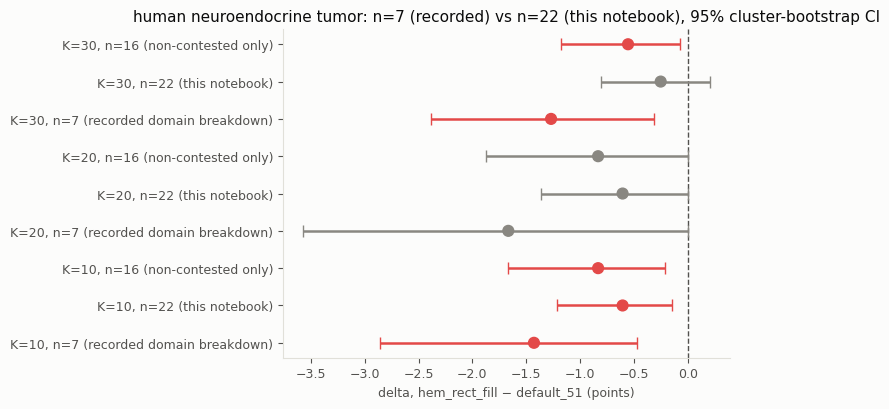

-> neuro_followup_n7_vs_n22_forest.png


In [12]:
fig, ax = plt.subplots(figsize=(7.5, 4.2), facecolor='#fcfcfb')
ax.set_facecolor('#fcfcfb')
BLUE, RED, GRAY, INK, MUTED, GRID = '#2a78d6', '#e34948', '#898781', '#0b0b0b', '#52514e', '#e1e0d9'

rows_plot = disp.sort_values(['K', 'n'], ascending=[True, False]).reset_index(drop=True)
y = np.arange(len(rows_plot))
colors = [BLUE if (r.ci_excludes_0 and r.pooled_delta_precision > 0) else RED if (r.ci_excludes_0 and r.pooled_delta_precision < 0) else GRAY for r in rows_plot.itertuples()]
xerr_lo = np.maximum(0, rows_plot['pooled_delta_precision'] - rows_plot['ci_low'])
xerr_hi = np.maximum(0, rows_plot['ci_high'] - rows_plot['pooled_delta_precision'])
for yi, (xv, elo, ehi, c) in enumerate(zip(rows_plot['pooled_delta_precision'], xerr_lo, xerr_hi, colors)):
    ax.errorbar([xv], [yi], xerr=[[elo], [ehi]], fmt='none', ecolor=c, elinewidth=1.8, capsize=4, zorder=2)
ax.scatter(rows_plot['pooled_delta_precision'], y, c=colors, s=60, zorder=3)
ax.axvline(0, color=MUTED, linewidth=1, linestyle='--', zorder=0)
ax.set_yticks(y)
ax.set_yticklabels([f"K={r.K}, {r.n}" for r in rows_plot.itertuples()], fontsize=9, color=INK)
ax.set_xlabel('delta, hem_rect_fill − default_51 (points)', fontsize=9, color=MUTED)
ax.set_title(f'{DOMAIN}: n=7 (recorded) vs n=22 (this notebook), 95% cluster-bootstrap CI', fontsize=11, color=INK)
ax.tick_params(colors=MUTED, labelsize=9)
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)
for spine in ('left', 'bottom'):
    ax.spines[spine].set_color(GRID)
fig.tight_layout()
fig.savefig(FIG_PATHS['forest'], dpi=150, bbox_inches='tight', facecolor='#fcfcfb')
plt.show()
print(f"-> {FIG_PATHS['forest']}")

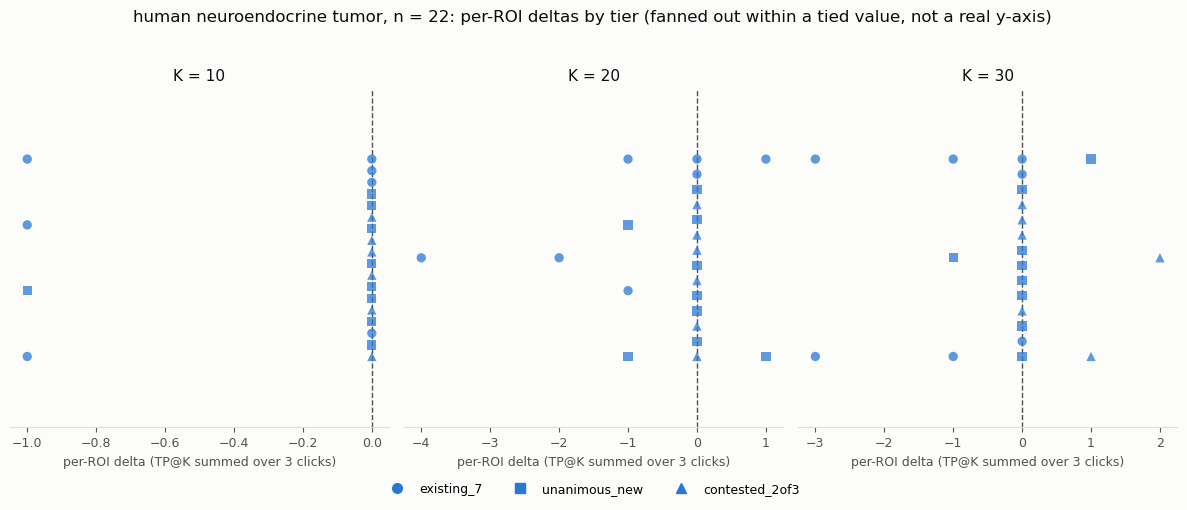

-> neuro_followup_22roi_strip.png

total notebook runtime: 14.8 min


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4.6), sharey=True, facecolor='#fcfcfb')
BLUE, INK, MUTED, GRID, SURFACE = '#2a78d6', '#0b0b0b', '#52514e', '#e1e0d9', '#fcfcfb'
TIER_MARKER = {'existing_7': 'o', 'unanimous_new': 's', 'contested_2of3': '^'}
tier_by_file = ROIS.set_index('file_name')['tier'].to_dict()

for ax, k in zip(axes, BUDGETS):
    ax.set_facecolor(SURFACE)
    sub = DELTA_22[DELTA_22['K'] == k].copy()
    # deterministic beeswarm: ROIs tied at the same delta fan out in y, symmetrically, so no ROI is
    # hidden behind another -- this domain is tie-heavy (see Cell 11's W/L/T), so plain y=0 would
    # collapse most of the 22 points onto a handful of visually indistinguishable markers
    sub['y'] = 0.0
    for _, idx in sub.groupby('delta_tp_sum').groups.items():
        n = len(idx)
        if n > 1:
            sub.loc[idx, 'y'] = np.linspace(-0.35, 0.35, n)
    for _, row in sub.iterrows():
        marker = TIER_MARKER[tier_by_file[row['file_name']]]
        ax.scatter(row['delta_tp_sum'], row['y'], marker=marker, color=BLUE, alpha=0.75, s=45, zorder=2, edgecolors='none')
    ax.axvline(0, color=MUTED, linewidth=1, linestyle='--', zorder=0)
    ax.set_ylim(-0.6, 0.6)
    ax.set_title(f'K = {k}', fontsize=11, color=INK)
    ax.set_xlabel('per-ROI delta (TP@K summed over 3 clicks)', fontsize=9, color=MUTED)
    ax.set_yticks([])
    ax.tick_params(colors=MUTED, labelsize=9)
    for spine in ('top', 'right', 'left'):
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color(GRID)

handles = [mlines.Line2D([], [], color=BLUE, marker=m, linestyle='none', markersize=7, label=t) for t, m in TIER_MARKER.items()]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.05))
fig.suptitle(f'{DOMAIN}, n = {len(ROI_ORDER)}: per-ROI deltas by tier (fanned out within a tied value, not a real y-axis)', fontsize=12, color=INK, y=1.03)
fig.tight_layout()
fig.savefig(FIG_PATHS['strip'], dpi=150, bbox_inches='tight', facecolor=SURFACE)
plt.show()
print(f"-> {FIG_PATHS['strip']}")
print(f"\ntotal notebook runtime: {(time.time() - NB_T0) / 60:.1f} min")

## Results

Every number below is printed by a cell above. "Points" are percentage points of precision. Every
delta is `hem_rect_fill - default_51`.

**Correctness (Cells 2-9).** 22/22 pulled ROIs pass their basic checks; 66/66 clicks assembled (21
reused verbatim from the recorded `hemrectfill` run + 45 freshly drawn, 3 retries total across the 15
new ROIs). The 7 `existing_7` ROIs reproduce the recorded run's `n_peaks`/`n_detections`/`n_self_hits`/
TP@K on all **42/42** (click, arm) pairs. All halt checks passed (budget delivered, `od` sane, one row
per arm per click, no candidate within one match radius of its own click). `n_peaks == MAX_PEAKS` on
132/132 runs.

**Pooled precision, n = 22 (Cell 9).**

| K | `default_51` | `hem_rect_fill` |
|---|---|---|
| 10 | 0.2697 (178/660) | 0.2636 (174/660) |
| 20 | 0.2129 (281/1320) | 0.2068 (273/1320) |
| 30 | 0.1843 (365/1980) | 0.1818 (360/1980) |

**n = 7 (recorded) vs. n = 22 (this notebook) vs. n = 16 non-contested sensitivity (Cell 11).**
Bold = bootstrap 95% CI excludes 0.

| K | n = 7 | n = 16 (non-contested) | n = 22 (full) |
|---|---|---|---|
| 10 | **-1.43** [-2.86, -0.48], W0/L3/T4, holm=1 | **-0.83** [-1.67, -0.21], W0/L4/T12, holm=.375 | **-0.61** [-1.21, -0.15], W0/L4/T18, holm=.375 |
| 20 | -1.67 [-3.57, 0.00], W1/L4/T2, holm=1 | -0.83 [-1.88, 0.00], W2/L6/T8, holm=.375 | -0.61 [-1.36, 0.00], W2/L6/T14, holm=.375 |
| 30 | **-1.27** [-2.38, -0.32], W0/L4/T3, holm=.875 | **-0.56** [-1.18, -0.07], W1/L5/T10, holm=.375 | -0.25 [-0.81, 0.20], W3/L5/T14, holm=.461 |

**Reading this.** The direction never flips: every cell, at every n and every K, is <= 0 -- `hem_rect_fill`
is never ahead of `default_51` in this domain, in this sample. But the **magnitude shrinks monotonically
as n grows**, at all three K: -1.43 -> -0.83 -> -0.61 pts (K=10), -1.67 -> -0.83 -> -0.61 (K=20),
-1.27 -> -0.56 -> -0.25 (K=30). That is the opposite of what more data does to a real, stable effect
(narrower CIs around a similar centre) -- it is the signature of the original n = 7 point estimate
being an unusually large draw from a noisy small sample, regressing toward a smaller (and, at K=30,
no-longer-resolvable) value as n triples.

**By K:**
- **K = 10** is the one budget where the CI excludes 0 at every n tried, including the full n = 22 -- the
  most robust piece of this result, though "robust" here still means a small, Holm-non-significant
  effect (holm p = .375 at both n = 16 and n = 22).
- **K = 20** never excludes 0, at any n -- no difference detected at this budget, full stop.
- **K = 30** is where n = 22 and n = 16 disagree: the 16 non-contested ROIs alone still exclude 0
  (-0.56 [-1.18, -0.07]), but adding the 6 contested-tier ROIs pulls the pooled delta to -0.25 and the
  CI now includes 0. Arithmetically, the 6 contested-tier ROIs sum to **+3 TP@30** against the 16
  non-contested ROIs' -8 -- i.e. those 6 ROIs point the *other* way on average at K=30, which is why
  full-sample n = 22 reads weaker than the cleaner n = 16 subset at that budget specifically.
- **No cell, at any n, survives Holm correction** at the conventional 0.05 level (best holm p = .375).

**What this establishes.** Tripling the domain's usable sample (7 -> 22, essentially the whole domain
short of the least-reliable annotation tier) did not firm up the n = 7 finding -- it shrank it, and at
the most-powered budget (K = 30) made it disappear in the full sample. Combined with never once
resolving past Holm correction, the honest conclusion is that `human neuroendocrine tumor` does **not**
have an established `hem_rect_fill` effect in either direction. The K=10 result (consistently
CI-excluding, small, shrinking) is the closest thing to a real, durable signal here, and even that is
not resolved by any conventional standard.

**Scope, read together with the pipeline-version note above.** This is a measurement of the **pre-D11**
pipeline (self-hit-disc filtering), pinned deliberately to stay poolable with the recorded n = 7 result.
It says nothing about whether the same question would come out differently under current (D11)
production -- that would need its own from-scratch measurement, not an extension of this one.